In [28]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from PIL import Image

In [75]:
class Map:
    def __init__(self, n, R):
        self.map = np.random.randint(2, size = (n,n))
        self.size = n
        self.neighbors = np.empty((n,n))
        self.changing = np.empty((n,n), dtype = bool)
        self.r = R
        self.moving = np.empty(3, dtype = int)


    def print_map(self):
        plt.figure()
        plt.imshow(self.map, cmap = 'Greys' )
        
    def find_neighbors(self):
        for i in range(self.size):
            for j in range(self.size):
                if i == 0 and j == 0:
                    self.neighbors[i,j] = (self.map[i,j+1] + self.map[i+1,j] + self.map[i+1,j+1])#/3
                    
                elif i == 0 and j != 0 and j != self.size - 1:
                    self.neighbors[i,j] = (self.map[i,j-1] + self.map[i+1,j-1] + self.map[i,j+1] + 
                                           self.map[i+1,j] + self.map[i+1,j+1])#/5
                    
                elif i == 0 and j == self.size - 1:
                    self.neighbors[i,j] = (self.map[i,j-1] + self.map[i+1,j] + self.map[i+1,j-1])#/3
                    
                elif i != 0 and i != self.size - 1 and j == 0:
                    self.neighbors[i,j] = (self.map[i,j+1] + self.map[i+1,j] + self.map[i-1,j] + 
                                           self.map[i+1,j+1] + self.map[i-1,j+1])#/5
                
                elif i == self.size - 1 and j == 0:
                    self.neighbors[i,j] = (self.map[i-1,j] + self.map[i,j+1] + self.map[i-1,j+1])#/3
                    
                elif i != 0 and i != self.size - 1 and j == self.size - 1:
                    self.neighbors[i,j] = (self.map[i,j-1] + self.map[i+1,j] + self.map[i-1,j] + 
                                           self.map[i+1,j-1] + self.map[i-1,j-1])#/5
                    
                elif i == self.size - 1 and j == self.size - 1:
                    self.neighbors[i,j] = (self.map[i-1,j] + self.map[i,j-1] + self.map[i-1,j-1])#/3
                    
                elif i == self.size - 1 and j != 0 and j != self.size - 1:
                    self.neighbors[i,j] = (self.map[i,j-1] + self.map[i-1,j-1] + self.map[i,j+1] + 
                                           self.map[i-1,j] + self.map[i-1,j+1])#/5
                    
                else: 
                    self.neighbors[i,j] = (self.map[i,j-1] + self.map[i,j+1] + self.map[i-1,j-1] + self.map[i-1,j] + 
                                           self.map[i-1,j+1] + self.map[i+1,j-1] + self.map[i+1,j] + self.map[i+1,j+1])#/8
                    
    def get_neighbors_changing(self):
#         self.r = 0.5
        self.find_neighbors()
        self.want_to_change()
        print(self.neighbors)
        print(self.changing)
        print(self.moving)
        
    def want_to_change(self):
        self.moving = np.empty(3, dtype = int)
        for i in range(self.size):
            for j in range(self.size):
                if self.map[i,j] == 0:
                    if 8 - self.neighbors[i,j] < self.r:
                        self.changing[i,j] = True
                        self.moving = np.vstack([self.moving, [i,j, 0]])
                    else:
                        self.changing[i,j] = False
                
                if self.map[i,j] == 1:
                    if self.neighbors[i,j] < self.r:
                        self.changing[i,j] = True
                        self.moving = np.vstack([self.moving, [i,j, 1]])
                    else:
                        self.changing[i,j] = False

    def new_map(self):
        self.find_neighbors()
        self.want_to_change()
        if self.moving.size == 3:
            return
        ran = self.moving[1:,2]
        np.random.shuffle(ran)
        self.moving[1:,2] = ran
        for k in self.moving[1:,:]:
            self.map[k[0], k[1]] = k[2]
            

    def evolution(self, n):
        for i in range(n):
            self.new_map()
#             plt.figure()
#             plt.imshow(self.changing )
#             plt.figure()
            plt.imshow(self.map, cmap = 'Greys' )
            plt.savefig(f'pictures_life/{self.r}_{i}.png', dpi = 400)
        
            
    def get_size(self):
        return(self.size)
    
    def number_wtm(self, n):
        wtm = np.array([])
        for i in range(n):
            self.new_map()
#             plt.figure()
#             plt.imshow(self.map, cmap = 'Greys' )
#             plt.savefig(f'pic/{self.r}_{i}.png', dpi = 400)
            wtm = np.append(wtm, self.changing.sum())
#             print(wtm, self.moving)
        return wtm

In [37]:
ab = np.array([])
ab = np.append(ab,1)
np.append(ab,1)

array([1., 1.])

In [63]:
ab = np.random.randint(2, size = (5,5), dtype = bool)
print(ab.sum(), ab)

11 [[ True False False  True  True]
 [ True  True False False  True]
 [False False  True  True False]
 [ True False False False  True]
 [False False False  True False]]


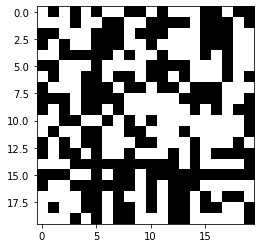

In [16]:
for i in range(9):
    m = Map(20, i)
    m.evolution(10)

In [32]:
files = [f for f in listdir('pictures_life')]


image_list = [Image.open('pictures_life/' + file) for file in files]


for i in range(9):
    image_list[i*10].save(
            f'animation_{i}.gif',
            save_all=True,
            append_images=image_list[i*10+1:(i+1)*10], # append rest of the images
            duration=300, # in milliseconds
            loop=0)

Text(0.5, 1.0, 'Number of households that want to move vs. time')

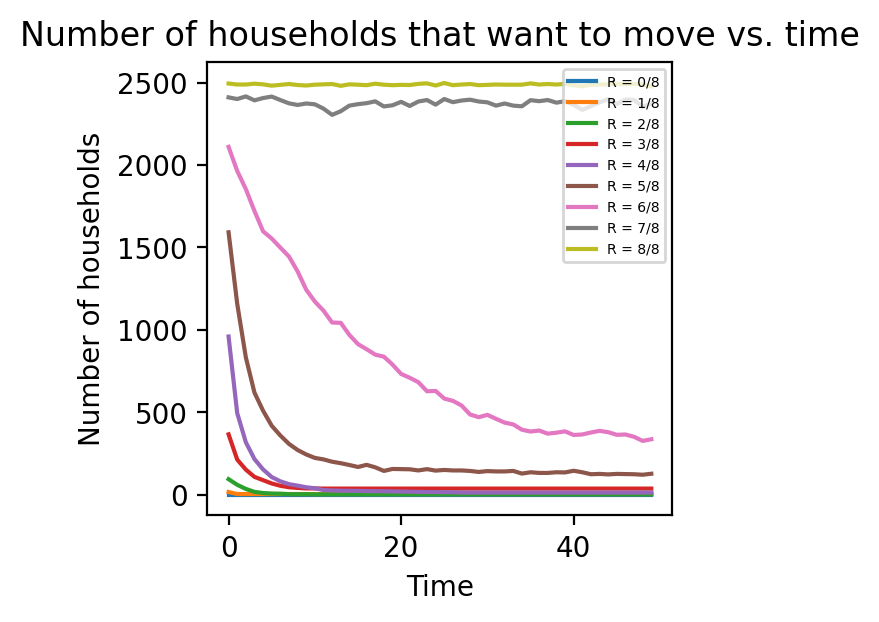

In [83]:
plt.figure(figsize = (3,3), dpi = 200)
for i in range(9):
    m = Map(50,i)
    wtm = m.number_wtm(50)
#     print(i, wtm)
    plt.plot(wtm, label = f'R = {i}/8')
plt.xlabel('Time')
plt.ylabel('Number of households')
plt.legend(loc = 1, fontsize = 5)
plt.title('Number of households that want to move vs. time')